# 01_回归算法-随机森林回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊随机森林回归\~

**随机森林回归（Random Forest Regression）是一种用来做预测的机器学习方法，它本质上是一个由很多棵决策树**组成的“森林”。

可以把它想象成一个**「集体投票」的过程**，每棵树都会给出自己的预测结果，最后让这些树的平均值作为最终答案。

比如你想预测一个房子的价格，可以找很多个房产专家来估价，每个专家根据自己的经验和数据做出预测，最后我们取所有专家给出的价格的平均值，这样得到的结果通常比单个专家预测的更准确、更稳定。这就是**随机森林回归的基本思想**——用多个决策树来减少单个模型的误差和偏差，让结果更加可靠！

#### 核心特点

1. **由很多棵决策树组成**：不是单靠一棵树，而是多个模型一起工作。
2. **每棵树都是随机训练的**：

   - 训练数据是**随机抽样**的（每棵树可能看到的数据都不一样）。
   - 选择特征（决定如何分裂树的条件）时也是**随机挑选**的。
3. **最终结果是所有树的预测值的平均值**，这样能减少单个模型的过拟合问题，提高泛化能力。

#### 它为什么好用？

- **稳定**：单棵树容易受到数据的影响，而多个树取平均值后，噪声和异常数据的影响会减小。
- **防止过拟合**：如果只有一棵决策树，可能会对训练数据过于敏感（即过拟合），但随机森林可以有效缓解这个问题。
- **适用于复杂关系**：即使数据的关系很复杂，随机森林也能很好地找到模式。

随机森林回归就是用**多个决策树**一起预测一个数值结果，通过**投票+平均值**的方式提高预测的准确性和稳定性，是一种非常好用的机器学习方法\~

## 原理详解

随机森林回归通过构建多个回归树并取平均预测值来提升准确性和泛化能力。

### 单棵回归决策树

随机森林是由多棵**回归决策树（Regression Tree）**组成，因此先回顾决策树回归的数学原理。

**回归树的目标**

给定一个训练数据集：


$$
D = \{(x_1, y_1), (x_2, y_2), ..., (x_N, y_N)\}
$$


其中，$x_i \in \mathbb{R}^d$是输入特征，$y_i \in \mathbb{R}$是对应的目标变量。

我们希望构建一个决策树来将输入特征空间划分成多个区域 $R_m$，并在每个区域内用**均值**作为预测值：  
$f(x) = \sum_{m=1}^{M} c_m \cdot \mathbb{I}(x \in R_m)$  
其中：

$R_m$是决策树分割出来的区域。

$c_m$是该区域内所有样本 $y_i$的均值：  
$c_m = \frac{1}{|R_m|} \sum_{x_i \in R_m} y_i$

$\mathbb{I}(x \in R_m)$是指示函数，表示样本 $x$是否属于区域 $R_m$。

**决策树的划分标准**

构造决策树时，我们需要在某个特征 $j$上选择一个最佳分割点 $s$，使得目标函数最优（最小化方差）。

对于一个分割点 $s$，数据被划分为左右两个区域：  
$R_{\text{left}}(j, s) = \{x_i | x_{ij} \leq s\}, \quad R_{\text{right}}(j, s) = \{x_i | x_{ij} > s\}$

我们希望选择一个 $(j, s)$使得目标函数（均方误差，MSE）最小：


$$
\underset{j, s}{\arg\min} \left[ \sum_{x_i \in R_{\text{left}}} (y_i - c_{\text{left}})^2 + \sum_{x_i \in R_{\text{right}}} (y_i - c_{\text{right}})^2 \right]
$$


其中：


$$
c_{\text{left}} = \frac{1}{|R_{\text{left}}|} \sum_{x_i \in R_{\text{left}}} y_i, \quad c_{\text{right}} = \frac{1}{|R_{\text{right}}|} \sum_{x_i \in R_{\text{right}}} y_i
$$


最终，我们使用递归的方法，逐步划分数据，直到满足停止条件（如最小叶子节点数、最大树深度等）。

### 随机森林回归的数学推导

**随机森林的基本思想**

随机森林由 $B$棵独立的回归树 $T_b(x)$组成，每棵树通过不同的样本和特征训练得到，最终的预测结果是所有树的平均值：  
$\hat{f}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$

其中：

$B$是树的数量。

$T_b(x)$是第 $b$棵树对输入 $x$的预测。

**误差分析**

假设每棵回归树的预测值可以表示为：  
$T_b(x) = f(x) + \varepsilon_b$  
其中：

$f(x)$是真实的目标函数。

$\varepsilon_b$是随机误差，满足均值为 0，方差为 $\sigma^2$。

随机森林的最终预测值为：  
$\hat{f}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x) = f(x) + \frac{1}{B} \sum_{b=1}^{B} \varepsilon_b$

假设误差 $\varepsilon_b$是独立同分布的，则随机森林的方差：  
$\text{Var}(\hat{f}(x)) = \frac{\sigma^2}{B}$

当 $B$增大时，方差降低，说明随机森林比单棵决策树更加稳定。

### 随机森林回归的算法流程

**造训练集（Bootstrap 采样）**

从原始数据集中**随机有放回**地抽取 $N$个样本，构建一个子数据集 $D_b$（与原数据集大小相同，但可能包含重复样本）。

**建决策树**

对于每个子数据集 $D_b$，训练一棵决策树，过程中：

1. 在每个节点随机选择 $m$个特征（$m < d$），然后选择最优特征进行分裂。
2. 递归划分数据，直到达到停止条件。

**复构建** $B$**棵树**

重复步骤 1 和 2，共训练 $B$棵不同的回归树。

对于新输入 $x$，每棵树 $T_b(x)$进行预测，最终预测值是所有树的**均值**：  
$\hat{f}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$

随机森林回归通过**集成多棵随机采样的决策树**，减少单个模型的过拟合，提高预测准确性。

它的数学基础主要包括**决策树的方差最小化**和**Bootstrap 采样的集成学习**，最终通过取均值得到稳定的预测值。

## 完整案例

这里，咱们使用 **加利福尼亚房价数据集** (`California Housing dataset`) 进行**随机森林回归**建模，完整流程如下：

1. 数据加载与预处理
2. 数据可视化（特征分布、相关性分析）
3. 构建随机森林回归模型
4. 超参数优化（`GridSearchCV`）
5. 模型评估（MSE、R²、残差分析）
6. 结果可视化（实际 vs 预测）

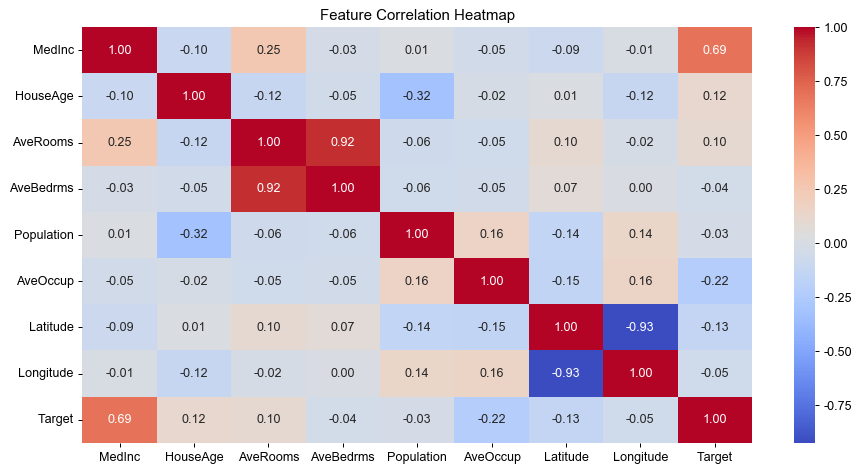

Mean Squared Error: 3843253360.45
R² Score: 0.69


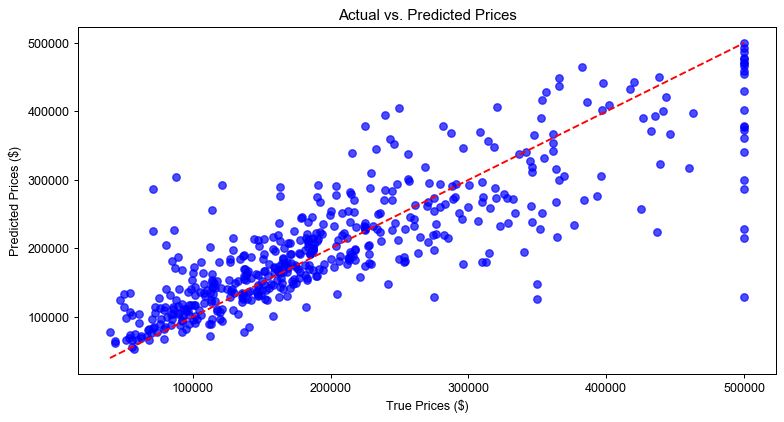

Optimized MSE: 3843253360.45
Optimized R²: 0.69


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 加载加利福尼亚房价数据集
data = load_local_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target * 100000  # 转换单位（单位：美元）

# 2. 数据可视化
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# 3. 数据拆分
X = df.drop(columns=["Target"])
y = df["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 训练随机森林回归模型
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 5. 评估模型
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# 6. 结果可视化
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='b')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel("True Prices ($)")
plt.ylabel("Predicted Prices ($)")
plt.title("Actual vs. Predicted Prices")
plt.show()

# 7. 超参数优化
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring="r2", n_jobs=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 8. 使用最佳参数重新训练
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

# 9. 评估优化后模型
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print(f"Optimized MSE: {mse_best:.2f}")
print(f"Optimized R²: {r2_best:.2f}")

**数据可视化**：通过 **相关性热图** 发现哪些特征对房价影响较大（例如 `MedInc` 对 `Target` 影响较大）。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

**模型评估**：初始 `R²` 和 `MSE` 评估基本性能。

**优化模型**：通过 **超参数调优** (`n_estimators`, `max_depth`, `min_samples_split`) 提升预测性能。

**优化后结果**： `R²` 提升，`MSE` 降低，说明优化后模型更准确。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

## 模型分析

### 随机森林回归优缺点

**优点：**

1. **强大的非线性建模能力**：相比线性回归，随机森林可以捕捉复杂的非线性关系，非常适用于房价预测等涉及多种因素的任务。
2. **降低过拟合风险**：单棵决策树容易过拟合，但随机森林通过集成学习（多个决策树投票），使得模型更稳健。
3. **特征选择的重要性评估**：可以通过 `feature_importances_` 查看各个特征的重要程度，方便特征工程优化。
4. **鲁棒性强，对异常值不敏感**：由于是多个模型的平均值，单个异常数据不会极端影响预测结果。
5. **无需特征缩放**：不像 SVM 或线性回归需要归一化，随机森林不受特征尺度影响。

**缺点：**

1. **计算成本高**：相比单个决策树，随机森林需要训练多个树，计算开销大，尤其在超参数优化时会消耗大量资源。
2. **难以解释**：不像决策树可以直观地理解每个分裂条件，随机森林的多个树组合在一起，使得解释性较差。
3. **可能对高维稀疏数据不友好**：在数据维度非常高、稀疏性强（如 NLP 任务）时，随机森林可能不如线性模型或梯度提升树（GBDT）效果好。

### 随机森林回归 vs. 其他相似算法（对比表）

| **算法** | **适用场景** | **优点** | **缺点** |
|-|-|-|-|
| **随机森林回归** | 适用于特征多、数据量大且有非线性关系的任务，如房价预测、股票价格预测 | 抗过拟合、适用于非线性关系、能评估特征重要性 | 计算复杂度高，难以解释 |
| **决策树回归** | 适用于简单的回归任务，或者数据量较小的情况 | 易解释、计算速度快 | 容易过拟合，单棵树泛化能力差 |
| **梯度提升回归（GBDT，如 XGBoost, LightGBM）** | 适用于数据规模大、需要高准确度的场景，如金融风控、广告点击率预测 | 精度高，能自动处理缺失值，支持特征重要性评估 | 训练时间较长，参数调优复杂 |
| **线性回归** | 适用于特征之间关系近似线性，且数据分布良好的情况 | 计算快，解释性强 | 无法处理复杂的非线性关系，易受异常值影响 |
| **支持向量回归** | 适用于小数据集、高维数据，且需要高精度预测 | 适用于小样本，能找到最优超平面 | 计算复杂度高，不适合大数据 |

### 什么时候优选 随机森林回归，什么时候可以考虑其他算法？

**优选随机森林的情况：**

- 当数据的特征较多，并且这些特征之间可能存在非线性关系（如房价预测）。
- 当你希望降低过拟合，但仍然想保持较强的预测能力。
- 当你想要了解特征对预测的贡献度（`feature_importances_` 可用）。
- 当你不需要实时预测，而更关注预测的稳定性和准确度。

**考虑其他算法的情况：**

- **数据规模特别大时**，如数百万以上的样本，梯度提升树（如 XGBoost、LightGBM）可能比随机森林更快、更高效。
- **数据是高维稀疏数据（如 NLP 任务）**，随机森林不适用，而 Lasso 回归或神经网络可能更合适。
- **需要结果易解释的情况**，如医疗诊断、金融决策，可考虑决策树回归或线性回归，而不是随机森林。
- **需要实时预测的情况**，如推荐系统、在线广告点击率预测，梯度提升树（如 LightGBM）或简单的线性模型通常更快。

### 总结

本案例中，房价预测涉及多个因素，并且变量之间可能存在非线性关系，因此随机森林是一个较好的选择。但如果数据规模进一步增大，或者需要更高的预测精度，可能需要尝试 XGBoost 或 LightGBM 等更高效的集成学习方法。